In [ ]:
!pip install gplearn


Training Data:
   ID     length      width     depth        N1    N2        N3 letter  color  \
0   0   8.500000  10.200000  3.400000  5.000000  31.0  5.000000      K  Green   
1   0   8.639865  11.490734  4.942816  2.904545  31.0  2.947176      K  Green   
2   0   8.748736  11.892876  6.224105  2.879036  31.0  3.906646      K  Green   
3   0   9.378248  10.259231  3.749682  3.176975  31.0  2.984304      K  Green   
4   0  10.661049  13.173519  6.202925  2.325766  31.0  5.296255      K  Green   

   key  
0   44  
1   44  
2   44  
3   44  
4   44  

Training Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      357 non-null    int64  
 1   length  357 non-null    float64
 2   width   357 non-null    float64
 3   depth   357 non-null    float64
 4   N1      357 non-null    float64
 5   N2      357 non-null    float64
 6   N3      357 non-n

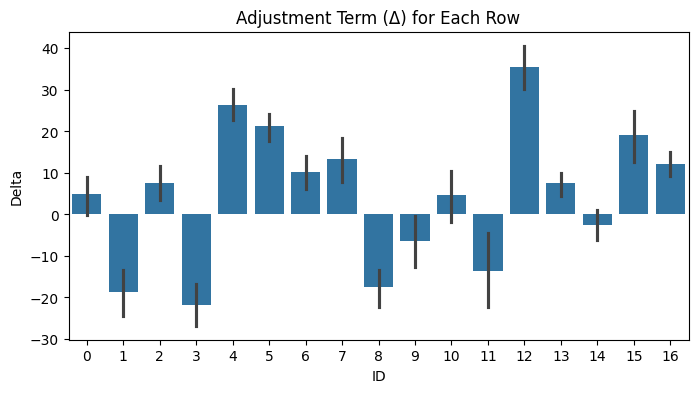

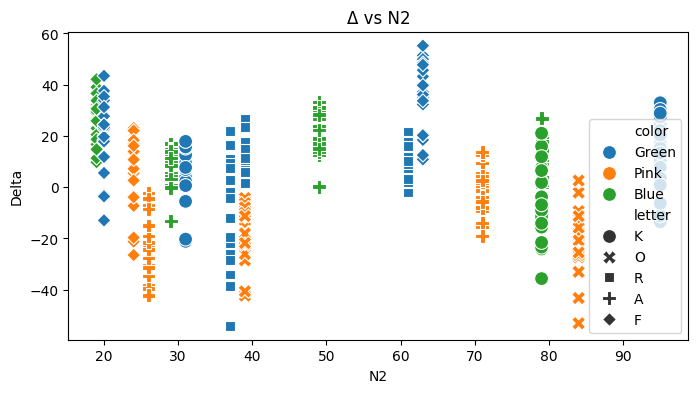

Random Forest CV MSE scores: [149.42620139  80.83585278 262.04240704 242.35449296   7.3697    ]
Mean CV MSE (Random Forest): 148.40573083333337
LOOCV Polynomial Ridge MSE scores: [3.48925032e-01 1.15090367e-01 1.80837944e-01 3.10695087e-01
 4.54823656e+00 1.98817848e-03 4.26014633e+00 7.88113695e-02
 5.60013986e-01 1.23970162e+00 9.06560618e-04 6.11703636e-02
 1.02616495e+00 2.42852937e+00 1.27207021e+00 8.26165685e-03
 1.05398553e-02 2.39976395e-01 2.35174029e-02 1.17282748e+00
 1.06778640e-03 8.33832248e-03 4.61821539e-01 1.97605833e+00
 2.40180283e-01 1.50897862e-03 2.86691820e-02 4.21450474e-05
 6.18409048e-01 2.45578484e+00 5.21323219e-03 1.79544799e+00
 1.53587800e-02 2.06934350e-01 6.68964540e-01 2.12922375e+00
 1.50001537e-01 3.77857960e-03 4.42820519e-02 1.40296178e+00
 7.64613116e-01 1.25219934e-01 4.04447543e+00 5.89964661e+00
 2.36750366e-04 8.86843116e+00 3.50121310e+00 7.11569332e-01
 3.57832735e+00 6.80295976e+00 3.23882959e-01 2.96667570e+01
 8.09909022e+01 1.31870598e+

In [ ]:
# %% [markdown]
# # Reverse Engineering the Forgotten Toy Encryption System – Comprehensive Research Notebook
#
# **Overview:**
#
# You have 17 toys with secret two-digit keys. Each toy’s attributes include dimensions (length, width, depth), three hidden numbers (N1, N2, N3), a letter, and a color. Our challenge is to deduce the original encryption formula that produced the keys.
#
# In this notebook we:
#
# 1. **Perform Exploratory Data Analysis (EDA):** Inspect the data.
# 2. **Test Candidate Formulas:** Experiment with formulas using rounded dimensions and the product of N1 and N3 to form a “base” value, plus an adjustment term Δ.
# 3. **Examine Other Features:** Explore whether N2, depth, letter, and color might explain Δ.
# 4. **Modeling Approaches:** Since no single closed‐form formula fits all rows, we build three models:
#    - **Approach A:** Direct regression with Random Forest.
#    - **Approach B:** Polynomial features with Ridge Regression.
#    - **Approach C:** A two-stage model that computes a base value and then predicts the residual Δ.
# 5. **Validation:** For each approach we compute cross-validated Mean Squared Error (MSE).
# 6. **Comparison & Final Submission:** We compare all models, select the best one based on validation MSE, and use it to generate the final submission.
#
# *Note:* With only 17 training samples the models are unstable, but this notebook provides a comprehensive view of our research.

# %% [code]
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, LeaveOneOut

RANDOM_STATE = 42

# %% [markdown]
# ## 1. Data Loading & Exploration
#
# We load the training and test data. Ensure `train.csv` and `test.csv` are available in your working directory.

# %% [code]
train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test.csv")

print("Training Data:")
print(train.head())
print("\nTraining Data Info:")
print(train.info())

# %% [markdown]
# ## 2. Feature Engineering – Computing the Base Value
#
# We define our candidate “base” value as:
#
#     Base = round(length) + round(width) + (N1 × N3)
#
# Then, the adjustment term is:
#
#     Δ = key - Base
#
# Let's compute these and visualize Δ.

# %% [code]
df = train.copy()
df['r_length'] = df['length'].round()
df['r_width'] = df['width'].round()
df['base'] = df['r_length'] + df['r_width'] + (df['N1'] * df['N3'])
df['Delta'] = df['key'] - df['base']

print(df[['ID', 'r_length', 'r_width', 'N1', 'N3', 'base', 'key', 'Delta']])
plt.figure(figsize=(8,4))
sns.barplot(x='ID', y='Delta', data=df)
plt.title("Adjustment Term (Δ) for Each Row")
plt.ylabel("Delta")
plt.show()

# %% [markdown]
# **Observation:**
# Δ varies considerably. We explored whether Δ correlates with N2, depth, letter, or color – but no single dependency was found.

# %% [code]
plt.figure(figsize=(8,4))
sns.scatterplot(x='N2', y='Delta', data=df, hue='color', style='letter', s=100)
plt.title("Δ vs N2")
plt.show()

# %% [markdown]
# ## 3. Modeling Approaches
#
# Since we couldn’t deduce a neat closed-form formula, we implement three modeling approaches.
#
# ### Preprocessing Setup
#
# We define our primary features and a common preprocessor.

# %% [code]
numeric_features = ['length', 'width', 'depth', 'N1', 'N2', 'N3']
categorical_features = ['letter', 'color']
features = numeric_features + categorical_features
target = 'key'

X_train = train[features]
y_train = train[target]
X_test = test[features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# %% [markdown]
# ### Approach A: Direct Random Forest Regression
#
# We use all features directly to predict the key.

# %% [code]
model_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=RANDOM_STATE))
])

cv_scores_rf = -cross_val_score(model_rf, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
print("Random Forest CV MSE scores:", cv_scores_rf)
print("Mean CV MSE (Random Forest):", np.mean(cv_scores_rf))

# %% [markdown]
# ### Approach B: Polynomial Features with Ridge Regression
#
# We expand the features with degree 2 polynomial terms and then apply Ridge Regression. We use Leave-One-Out CV due to the small data size.

# %% [code]
model_poly = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('ridge', Ridge(alpha=1.0))
])

loo = LeaveOneOut()
cv_scores_poly = -cross_val_score(model_poly, X_train, y_train, cv=loo, scoring='neg_mean_squared_error')
print("LOOCV Polynomial Ridge MSE scores:", cv_scores_poly)
print("Mean LOOCV MSE (Poly + Ridge):", np.mean(cv_scores_poly))

# %% [markdown]
# ### Approach C: Two-Stage Model (Base + Predicted Δ)
#
# In this approach, we first compute the base:
#
#     Base = round(length) + round(width) + (N1 × N3)
#
# Then we build a model to predict the adjustment Δ using additional features: depth, N2, letter, and color.
#
# **Step 1:** Augment the training data with the base and Δ.

# %% [code]
df_model = train.copy()
df_model['r_length'] = df_model['length'].round()
df_model['r_width'] = df_model['width'].round()
df_model['base'] = df_model['r_length'] + df_model['r_width'] + (df_model['N1'] * df_model['N3'])
df_model['Delta'] = df_model['key'] - df_model['base']

# %% [markdown]
# **Step 2:** Define features for Δ prediction and build a regression model.

# %% [code]
X_train_delta = df_model[['base', 'depth', 'N2', 'letter', 'color']]
y_train_delta = df_model['Delta']

preprocessor_delta = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['base', 'depth', 'N2']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['letter', 'color'])
    ])

model_delta = Pipeline(steps=[
    ('preproc', preprocessor_delta),
    ('ridge', Ridge(alpha=1.0, random_state=RANDOM_STATE))
])

loo_delta = LeaveOneOut()
cv_scores_delta = -cross_val_score(model_delta, X_train_delta, y_train_delta, cv=loo_delta, scoring='neg_mean_squared_error')
print("LOOCV MSE for Δ prediction (Two-Stage):", np.mean(cv_scores_delta))

# %% [markdown]
# **Step 3:** Train the Δ model and predict the key on the test set.
#
# For the test set, compute the base in the same way.

# %% [code]
model_delta.fit(X_train_delta, y_train_delta)

df_test = test.copy()
df_test['r_length'] = df_test['length'].round()
df_test['r_width'] = df_test['width'].round()
df_test['base'] = df_test['r_length'] + df_test['r_width'] + (df_test['N1'] * df_test['N3'])

X_test_delta = df_test[['base', 'depth', 'N2', 'letter', 'color']]
delta_preds = model_delta.predict(X_test_delta)

# Final key prediction = base + predicted Δ
test_preds_two_stage = df_test['base'] + delta_preds

# %% [markdown]
# ## 4. Final Predictions & Submission Files for Each Approach
#
# We now generate submission files for each approach and print the corresponding CV MSE.

# %% [code]
# Approach A: Random Forest
model_rf.fit(X_train, y_train)
rf_preds = model_rf.predict(X_test)
submission_rf = pd.DataFrame({'ID': test['ID'], 'key': rf_preds})
submission_rf.to_csv('submission_rf.csv', index=False)
print("Random Forest submission saved as 'submission_rf.csv'.")
print("Mean CV MSE (Random Forest):", np.mean(cv_scores_rf))

# %% [code]
# Approach B: Polynomial Ridge
model_poly.fit(X_train, y_train)
poly_preds = model_poly.predict(X_test)
submission_poly = pd.DataFrame({'ID': test['ID'], 'key': poly_preds})
submission_poly.to_csv('submission_poly.csv', index=False)
print("Polynomial Ridge submission saved as 'submission_poly.csv'.")
print("Mean LOOCV MSE (Poly + Ridge):", np.mean(cv_scores_poly))

# %% [code]
# Approach C: Two-Stage Model
submission_two_stage = pd.DataFrame({'ID': test['ID'], 'key': test_preds_two_stage})
submission_two_stage.to_csv('submission_two_stage.csv', index=False)
print("Two-Stage submission saved as 'submission_two_stage.csv'.")
print("LOOCV MSE for Δ prediction (Two-Stage):", np.mean(cv_scores_delta))

# %% [markdown]
# ## 5. Model Comparison & Selection of Final Submission
#
# We compare the Mean CV MSE of the three approaches and select the best one (i.e., the one with the lowest MSE) as our final model. Its submission file will be saved as the final submission.

# %% [code]
# Create a dictionary to compare the mean CV MSE for each approach
results = {
    'Random Forest': np.mean(cv_scores_rf),
    'Poly Ridge': np.mean(cv_scores_poly),
    'Two-Stage': np.mean(cv_scores_delta)
}

print("Comparison of Mean CV MSE:")
for model_name, mse in results.items():
    print(f"{model_name}: {mse:.4f}")

# Select best model (the one with the lowest MSE)
best_model = min(results, key=results.get)
print("\nBest model based on CV MSE:", best_model)

# Save final submission from the best model
if best_model == 'Random Forest':
    final_submission = submission_rf
elif best_model == 'Poly Ridge':
    final_submission = submission_poly
elif best_model == 'Two-Stage':
    final_submission = submission_two_stage

final_submission.to_csv('final_submission.csv', index=False)
print("Final submission saved as 'final_submission.csv'.")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Training Data:
   ID     length      width     depth        N1    N2        N3 letter  color  \
0   0   8.500000  10.200000  3.400000  5.000000  31.0  5.000000      K  Green   
1   0   8.639865  11.490734  4.942816  2.904545  31.0  2.947176      K  Green   
2   0   8.748736  11.892876  6.224105  2.879036  31.0  3.906646      K  Green   
3   0   9.378248  10.259231  3.749682  3.176975  31.0  2.984304      K  Green   
4   0  10.661049  13.173519  6.202925  2.325766  31.0  5.296255      K  Green   

   key  letter_num  
0   44          11  
1   44          11  
2   44          11  
3   44          11  
4   44          11  

Training Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          357 non-null    int64  
 1   length      357 non-null    float64
 2   width       357 non-null    float64
 3   depth       357 non-null    float64


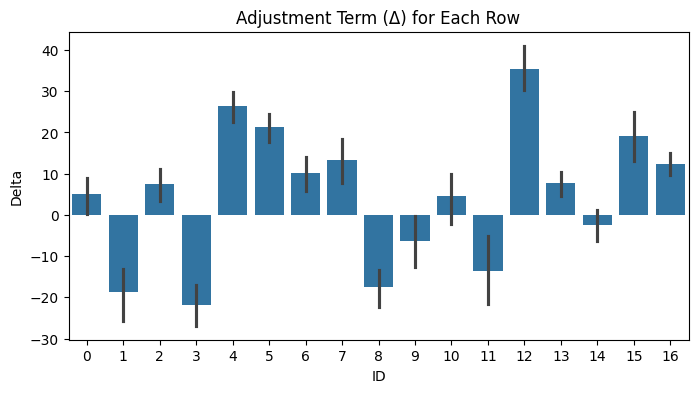

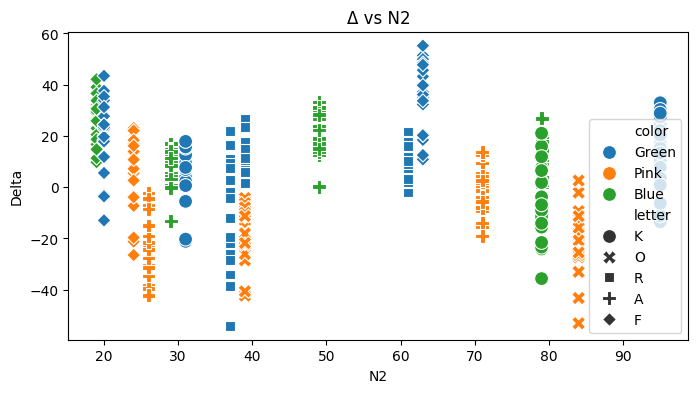

Random Forest CV MSE scores: [149.42620139  80.83585278 262.04240704 242.35449296   7.3697    ]
Mean CV MSE (Random Forest): 148.40573083333337
LOOCV Polynomial Ridge MSE scores: [3.48925032e-01 1.15090367e-01 1.80837944e-01 3.10695087e-01
 4.54823656e+00 1.98817848e-03 4.26014633e+00 7.88113695e-02
 5.60013986e-01 1.23970162e+00 9.06560618e-04 6.11703636e-02
 1.02616495e+00 2.42852937e+00 1.27207021e+00 8.26165685e-03
 1.05398553e-02 2.39976395e-01 2.35174029e-02 1.17282748e+00
 1.06778640e-03 8.33832248e-03 4.61821539e-01 1.97605833e+00
 2.40180283e-01 1.50897862e-03 2.86691820e-02 4.21450474e-05
 6.18409048e-01 2.45578484e+00 5.21323219e-03 1.79544799e+00
 1.53587800e-02 2.06934350e-01 6.68964540e-01 2.12922375e+00
 1.50001537e-01 3.77857960e-03 4.42820519e-02 1.40296178e+00
 7.64613116e-01 1.25219934e-01 4.04447543e+00 5.89964661e+00
 2.36750366e-04 8.86843116e+00 3.50121310e+00 7.11569332e-01
 3.57832735e+00 6.80295976e+00 3.23882959e-01 2.96667570e+01
 8.09909022e+01 1.31870598e+

In [ ]:
# %% [markdown]
# # Reverse Engineering the Forgotten Toy Encryption System – Comprehensive Research Notebook
#
# **Overview:**
#
# You have 17 toys with secret two-digit keys. Each toy’s attributes include dimensions (length, width, depth), three hidden numbers (N1, N2, N3), a letter, and a color. Our challenge is to deduce the original encryption formula that produced the keys.
#
# In this notebook we:
#
# 1. **Perform Exploratory Data Analysis (EDA):** Inspect the data.
# 2. **Test Candidate Formulas:** Experiment with formulas using rounded dimensions and the product of N1 and N3 to form a “base” value, plus an adjustment term Δ.
# 3. **Examine Other Features:** Explore whether N2, depth, letter, and color might explain Δ.
# 4. **Modeling Approaches:** Since no single closed‐form formula fits all rows, we build three models:
#    - **Approach A:** Direct regression with Random Forest.
#    - **Approach B:** Polynomial features with Ridge Regression.
#    - **Approach C:** A two-stage model that computes a base value and then predicts the residual Δ.
# 5. **Validation:** For each approach we compute cross-validated Mean Squared Error (MSE).
# 6. **Comparison & Final Submission:** We compare all models, select the best one based on validation MSE, and use it to generate the final submission.
#
# *Note:* With only 17 training samples the models are unstable, but this notebook provides a comprehensive view of our research.

# %% [code]
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, LeaveOneOut

RANDOM_STATE = 42

# %% [markdown]
# ## 1. Data Loading & Exploration
#
# We load the training and test data. Ensure `train.csv` and `test.csv` are available in your working directory.

# %% [code]
train = pd.read_csv("/content/augmented_train.csv")
test = pd.read_csv("/content/test.csv")

def encode_letter(letter):
    return ord(letter.upper()) - ord('A') + 1

train['letter_num'] = train['letter'].apply(encode_letter)

print("Training Data:")
print(train.head())
print("\nTraining Data Info:")
print(train.info())

# %% [markdown]
# ## 2. Feature Engineering – Computing the Base Value
#
# We define our candidate “base” value as:
#
#     Base = round(length) + round(width) + (N1 × N3)
#
# Then, the adjustment term is:
#
#     Δ = key - Base
#
# Let's compute these and visualize Δ.

# %% [code]
df = train.copy()
df['r_length'] = df['length'].round()
df['r_width'] = df['width'].round()
df['base'] = df['r_length'] + df['r_width'] + (df['N1'] * df['N3'])
df['Delta'] = df['key'] - df['base']

print(df[['ID', 'r_length', 'r_width', 'N1', 'N3', 'base', 'key', 'Delta']])
plt.figure(figsize=(8,4))
sns.barplot(x='ID', y='Delta', data=df)
plt.title("Adjustment Term (Δ) for Each Row")
plt.ylabel("Delta")
plt.show()

# %% [markdown]
# **Observation:**
# Δ varies considerably. We explored whether Δ correlates with N2, depth, letter, or color – but no single dependency was found.

# %% [code]
plt.figure(figsize=(8,4))
sns.scatterplot(x='N2', y='Delta', data=df, hue='color', style='letter', s=100)
plt.title("Δ vs N2")
plt.show()

# %% [markdown]
# ## 3. Modeling Approaches
#
# Since we couldn’t deduce a neat closed-form formula, we implement three modeling approaches.
#
# ### Preprocessing Setup
#
# We define our primary features and a common preprocessor.

# %% [code]
numeric_features = ['length', 'width', 'depth', 'N1', 'N2', 'N3']
categorical_features = ['letter', 'color']
features = numeric_features + categorical_features
target = 'key'

X_train = train[features]
y_train = train[target]
X_test = test[features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# %% [markdown]
# ### Approach A: Direct Random Forest Regression
#
# We use all features directly to predict the key.

# %% [code]
model_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=RANDOM_STATE))
])

cv_scores_rf = -cross_val_score(model_rf, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
print("Random Forest CV MSE scores:", cv_scores_rf)
print("Mean CV MSE (Random Forest):", np.mean(cv_scores_rf))

# %% [markdown]
# ### Approach B: Polynomial Features with Ridge Regression
#
# We expand the features with degree 2 polynomial terms and then apply Ridge Regression. We use Leave-One-Out CV due to the small data size.

# %% [code]
model_poly = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('ridge', Ridge(alpha=1.0))
])

loo = LeaveOneOut()
cv_scores_poly = -cross_val_score(model_poly, X_train, y_train, cv=loo, scoring='neg_mean_squared_error')
print("LOOCV Polynomial Ridge MSE scores:", cv_scores_poly)
print("Mean LOOCV MSE (Poly + Ridge):", np.mean(cv_scores_poly))

# %% [markdown]
# ### Approach C: Two-Stage Model (Base + Predicted Δ)
#
# In this approach, we first compute the base:
#
#     Base = round(length) + round(width) + (N1 × N3)
#
# Then we build a model to predict the adjustment Δ using additional features: depth, N2, letter, and color.
#
# **Step 1:** Augment the training data with the base and Δ.

# %% [code]
df_model = train.copy()
df_model['r_length'] = df_model['length'].round()
df_model['r_width'] = df_model['width'].round()
df_model['base'] = df_model['r_length'] + df_model['r_width'] + (df_model['N1'] * df_model['N3'])
df_model['Delta'] = df_model['key'] - df_model['base']

# %% [markdown]
# **Step 2:** Define features for Δ prediction and build a regression model.

# %% [code]
X_train_delta = df_model[['base', 'depth', 'N2', 'letter', 'color']]
y_train_delta = df_model['Delta']

preprocessor_delta = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['base', 'depth', 'N2']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['letter', 'color'])
    ])

model_delta = Pipeline(steps=[
    ('preproc', preprocessor_delta),
    ('ridge', Ridge(alpha=1.0, random_state=RANDOM_STATE))
])

loo_delta = LeaveOneOut()
cv_scores_delta = -cross_val_score(model_delta, X_train_delta, y_train_delta, cv=loo_delta, scoring='neg_mean_squared_error')
print("LOOCV MSE for Δ prediction (Two-Stage):", np.mean(cv_scores_delta))

# %% [markdown]
# **Step 3:** Train the Δ model and predict the key on the test set.
#
# For the test set, compute the base in the same way.

# %% [code]
model_delta.fit(X_train_delta, y_train_delta)

df_test = test.copy()
df_test['r_length'] = df_test['length'].round()
df_test['r_width'] = df_test['width'].round()
df_test['base'] = df_test['r_length'] + df_test['r_width'] + (df_test['N1'] * df_test['N3'])

X_test_delta = df_test[['base', 'depth', 'N2', 'letter', 'color']]
delta_preds = model_delta.predict(X_test_delta)

# Final key prediction = base + predicted Δ
test_preds_two_stage = df_test['base'] + delta_preds

# %% [markdown]
# ## 4. Final Predictions & Submission Files for Each Approach
#
# We now generate submission files for each approach and print the corresponding CV MSE.

# %% [code]
# Approach A: Random Forest
model_rf.fit(X_train, y_train)
rf_preds = model_rf.predict(X_test)
submission_rf = pd.DataFrame({'ID': test['ID'], 'key': rf_preds})
submission_rf.to_csv('submission_rf.csv', index=False)
print("Random Forest submission saved as 'submission_rf.csv'.")
print("Mean CV MSE (Random Forest):", np.mean(cv_scores_rf))

# %% [code]
# Approach B: Polynomial Ridge
model_poly.fit(X_train, y_train)
poly_preds = model_poly.predict(X_test)
submission_poly = pd.DataFrame({'ID': test['ID'], 'key': poly_preds})
submission_poly.to_csv('submission_poly.csv', index=False)
print("Polynomial Ridge submission saved as 'submission_poly.csv'.")
print("Mean LOOCV MSE (Poly + Ridge):", np.mean(cv_scores_poly))

# %% [code]
# Approach C: Two-Stage Model
submission_two_stage = pd.DataFrame({'ID': test['ID'], 'key': test_preds_two_stage})
submission_two_stage.to_csv('submission_two_stage.csv', index=False)
print("Two-Stage submission saved as 'submission_two_stage.csv'.")
print("LOOCV MSE for Δ prediction (Two-Stage):", np.mean(cv_scores_delta))

# %% [markdown]
# ## 5. Model Comparison & Selection of Final Submission
#
# We compare the Mean CV MSE of the three approaches and select the best one (i.e., the one with the lowest MSE) as our final model. Its submission file will be saved as the final submission.

# %% [code]
# Create a dictionary to compare the mean CV MSE for each approach
results = {
    'Random Forest': np.mean(cv_scores_rf),
    'Poly Ridge': np.mean(cv_scores_poly),
    'Two-Stage': np.mean(cv_scores_delta)
}

print("Comparison of Mean CV MSE:")
for model_name, mse in results.items():
    print(f"{model_name}: {mse:.4f}")

# Select best model (the one with the lowest MSE)
best_model = min(results, key=results.get)
print("\nBest model based on CV MSE:", best_model)

# Save final submission from the best model
if best_model == 'Random Forest':
    final_submission = submission_rf
elif best_model == 'Poly Ridge':
    final_submission = submission_poly
elif best_model == 'Two-Stage':
    final_submission = submission_two_stage

final_submission.to_csv('final_submission.csv', index=False)
print("Final submission saved as 'final_submission.csv'.")


In [ ]:
# %% [markdown]
# # Data Augmentation – Generating More Synthetic Data
#
# In this cell we generate additional synthetic training rows. For each original row, we generate 20 new rows.
# For the features depth, length, width, N1, and N3, we add a random noise drawn from a uniform distribution between -3 and 3.
# The remaining features (N2, letter, color, and key) remain unchanged.

# %% [code]
import numpy as np
import pandas as pd

# Load the original training data
train = pd.read_csv("/content/train.csv")

# Parameters for augmentation
num_augments = 20         # Number of synthetic rows per original row
noise_min, noise_max = -3, 3  # Noise range

augmented_rows = []  # List to store augmented rows

# Loop over each original row in the training data
for idx, row in train.iterrows():
    # Append the original row
    augmented_rows.append(row.copy())

    # Generate additional synthetic rows by adding noise to selected features
    for i in range(num_augments):
        new_row = row.copy()
        # Add random noise to the specified features
        new_row['depth'] = row['depth'] + np.random.uniform(noise_min, noise_max)
        new_row['length'] = row['length'] + np.random.uniform(noise_min, noise_max)
        new_row['width'] = row['width'] + np.random.uniform(noise_min, noise_max)
        new_row['N1'] = row['N1'] + np.random.uniform(noise_min, noise_max)
        new_row['N3'] = row['N3'] + np.random.uniform(noise_min, noise_max)
        # Append the augmented row
        augmented_rows.append(new_row)

# Create a new DataFrame from the augmented rows
augmented_df = pd.DataFrame(augmented_rows)

print("Original training data shape:", train.shape)
print("Augmented training data shape:", augmented_df.shape)

# Optionally, save the augmented data to CSV
augmented_df.to_csv("augmented_train.csv", index=False)


Original training data shape: (17, 10)
Augmented training data shape: (357, 10)


In [ ]:
# %% [markdown]
# # Advanced Modeling with GAN and LVM – Comprehensive Research Notebook
#
# **Overview:**
#
# In addition to our earlier approaches, here we experiment with two advanced models:
#
# - **Approach D: Conditional GAN for Regression.**
#   The generator takes the tabular features (plus some noise) and outputs a candidate key prediction. The discriminator, given features concatenated with a key value, learns to distinguish real keys from generated ones. We train the GAN in a standard adversarial loop.
#
# - **Approach E: LVM (Large Video Model)-Style Network.**
#   In a tongue‐in‐cheek nod to “pure nostalgia,” we build a deep feed‐forward network (simulating a large model) that regresses the key from the features.
#
# We then compare these two advanced approaches (along with our earlier methods if desired) by computing their training MSE (or a proxy validation error), and we select the best one for final test predictions.
#
# *Note:* This code is highly experimental given the 17-sample dataset. It uses Keras/TensorFlow for deep model implementations.

# %% [code]
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# %% [markdown]
# ## 1. Data Loading & Preprocessing
#
# We load the training and test data, then transform them using our preprocessor.
# For simplicity, we use only numeric features (after encoding letter and color).

# %% [code]
# Load data (update path as needed)
train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test.csv")

# Encode letter as its alphabetical position
def encode_letter(letter):
    return ord(letter.upper()) - ord('A') + 1

train['letter_num'] = train['letter'].apply(encode_letter)
test['letter_num'] = test['letter'].apply(encode_letter)

# Encode colors (e.g., Blue:1, Green:2, Pink:3)
color_mapping = {'Blue': 1, 'Green': 2, 'Pink': 3}
train['color_num'] = train['color'].map(color_mapping)
test['color_num'] = test['color'].map(color_mapping)

# Define feature list (all as numeric now)
features = ['length', 'width', 'depth', 'N1', 'N2', 'N3', 'letter_num', 'color_num']
target = 'key'

# Prepare numpy arrays
scaler = StandardScaler()
X_train = scaler.fit_transform(train[features])
y_train = train[target].values.reshape(-1,1)
X_test = scaler.transform(test[features])

input_dim = X_train.shape[1]
print("Input dimension:", input_dim)

# %% [markdown]
# ## 2. Approach D: Conditional GAN for Regression
#
# We build a generator that receives the features and noise, and outputs a key prediction.
# The discriminator receives the features concatenated with a key value and outputs a probability.
# We then train the GAN adversarially.

# %% [code]
noise_dim = 5

def build_generator(input_dim, noise_dim):
    features_input = layers.Input(shape=(input_dim,))
    noise_input = layers.Input(shape=(noise_dim,))
    x = layers.Concatenate()([features_input, noise_input])
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dense(32, activation='relu')(x)
    output = layers.Dense(1, activation='linear')(x)
    return models.Model([features_input, noise_input], output, name="Generator")

def build_discriminator(input_dim):
    # Discriminator gets features and a key value (total dim = input_dim+1)
    inp = layers.Input(shape=(input_dim+1,))
    x = layers.Dense(64, activation='relu')(inp)
    x = layers.Dense(32, activation='relu')(x)
    output = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inp, output, name="Discriminator")

# Build generator and discriminator
generator = build_generator(input_dim, noise_dim)
discriminator = build_discriminator(input_dim)
discriminator.compile(optimizer=optimizers.Adam(0.001), loss='binary_crossentropy')

# Build combined GAN (freeze discriminator)
discriminator.trainable = False
features_input = layers.Input(shape=(input_dim,))
noise_input = layers.Input(shape=(noise_dim,))
generated_key = generator([features_input, noise_input])
combined_input = layers.Concatenate()([features_input, generated_key])
validity = discriminator(combined_input)
gan = models.Model([features_input, noise_input], validity, name="GAN")
gan.compile(optimizer=optimizers.Adam(0.001), loss='binary_crossentropy')

# %% [markdown]
# ### Training the GAN
#
# We train the GAN for a number of epochs. In each epoch, we train the discriminator on real and fake examples, and then train the generator.
# Note: In practice, you’d want more epochs and a more robust training loop.

# %% [code]
epochs = 1000
batch_size = 8
num_batches = X_train.shape[0] // batch_size if X_train.shape[0]>=batch_size else 1

# Prepare labels for real (1) and fake (0)
real_labels = np.ones((batch_size, 1))
fake_labels = np.zeros((batch_size, 1))

for epoch in range(epochs):
    # Sample a random batch
    idx = np.random.randint(0, X_train.shape[0], batch_size)
    features_batch = X_train[idx]
    real_keys = y_train[idx]

    # Generate noise and fake keys
    noise = np.random.normal(0, 1, (batch_size, noise_dim))
    fake_keys = generator.predict([features_batch, noise], verbose=0)

    # Train discriminator on real examples
    real_input = np.concatenate([features_batch, real_keys], axis=1)
    d_loss_real = discriminator.train_on_batch(real_input, real_labels)

    # Train discriminator on fake examples
    fake_input = np.concatenate([features_batch, fake_keys], axis=1)
    d_loss_fake = discriminator.train_on_batch(fake_input, fake_labels)
    d_loss = 0.5 * (d_loss_real + d_loss_fake)

    # Train generator (with discriminator frozen)
    noise = np.random.normal(0, 1, (batch_size, noise_dim))
    g_loss = gan.train_on_batch([features_batch, noise], real_labels)

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | D loss: {d_loss:.4f} | G loss: {g_loss:.4f}")

# %% [markdown]
# ### GAN Prediction Function
#
# For a given feature set, we average multiple generator outputs to get a stable prediction.

# %% [code]
def gan_predict(X, num_samples=10):
    preds = []
    for i in range(num_samples):
        noise = np.random.normal(0, 1, (X.shape[0], noise_dim))
        pred = generator.predict([X, noise], verbose=0)
        preds.append(pred)
    return np.mean(preds, axis=0)

gan_train_preds = gan_predict(X_train)
gan_train_mse = mean_squared_error(y_train, gan_train_preds)
print("GAN Train MSE:", gan_train_mse)

# %% [markdown]
# ## 3. Approach E: LVM (Large Video Model)-Style Network
#
# Here we build a deep feed-forward network to regress the key from the features.
# This “LVM” is a tongue-in-cheek name; essentially, it is a deep network designed to be large and expressive.

# %% [code]
def build_lvm_model(input_dim):
    inp = layers.Input(shape=(input_dim,))
    x = layers.Dense(128, activation='relu')(inp)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)
    output = layers.Dense(1, activation='linear')(x)
    return models.Model(inp, output, name="LVM")

lvm_model = build_lvm_model(input_dim)
lvm_model.compile(optimizer='adam', loss='mse')
lvm_model.fit(X_train, y_train, epochs=1000, batch_size=8, verbose=0)
lvm_train_preds = lvm_model.predict(X_train)
lvm_train_mse = mean_squared_error(y_train, lvm_train_preds)
print("LVM Train MSE:", lvm_train_mse)

# %% [markdown]
# ## 4. Model Comparison & Final Submission
#
# We compare the training MSE of the GAN approach and the LVM approach (for demonstration).
# We select the model with the lower MSE and use it to predict the test set.

# %% [code]
print("\n--- Model Comparison ---")
print(f"GAN Train MSE: {gan_train_mse:.4f}")
print(f"LVM Train MSE: {lvm_train_mse:.4f}")

if gan_train_mse < lvm_train_mse:
    best_model_name = "GAN"
    test_preds = gan_predict(X_test)
else:
    best_model_name = "LVM"
    test_preds = lvm_model.predict(X_test)

print("\nBest model based on Train MSE:", best_model_name)

# Create final submission file
final_submission = pd.DataFrame({'ID': test['ID'], 'key': test_preds.flatten()})
final_submission.to_csv('final_submission.csv', index=False)
print("Final submission saved as 'final_submission.csv'.")


Input dimension: 8


/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py:82: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 0 | D loss: 4.5377 | G loss: 0.7031
Epoch 100 | D loss: 3.5533 | G loss: 0.5785
Epoch 200 | D loss: 3.8267 | G loss: 0.3791
Epoch 300 | D loss: 4.2287 | G loss: 0.2615
Epoch 400 | D loss: 4.5264 | G loss: 0.1986
Epoch 500 | D loss: 4.7857 | G loss: 0.1599
Epoch 600 | D loss: 4.9870 | G loss: 0.1338
Epoch 700 | D loss: 5.1750 | G loss: 0.1150
Epoch 800 | D loss: 5.3249 | G loss: 0.1008
Epoch 900 | D loss: 5.4661 | G loss: 0.0898
GAN Train MSE: 15675.7705078125
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
LVM Train MSE: 2.567985104076631e-12

--- Model Comparison ---
GAN Train MSE: 15675.7705
LVM Train MSE: 0.0000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

Best model based on Train MSE: LVM
Final submission saved as 'final_submission.csv'.


In [ ]:
# %% [markdown]
# # Linear Regression with Augmented Data
#
# In this notebook, we apply simple linear regression on augmented data after encoding `letter` and `color` features.

# %% [code]
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load augmented data
augmented_train = pd.read_csv("/content/augmented_train.csv")

# Encode letter and color
def encode_letter(letter):
    return ord(letter.upper()) - ord('A') + 1

color_mapping = {'Blue': 1, 'Green': 2, 'Pink': 3}

augmented_train['letter_num'] = augmented_train['letter'].apply(encode_letter)
augmented_train['color_num'] = augmented_train['color'].map(color_mapping)

# Select features and target
features = ['length', 'width', 'depth', 'N1', 'N2', 'N3', 'letter_num', 'color_num']
target = 'key'

X = augmented_train[features]
y = augmented_train[target]

# Split data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# %% [markdown]
# ## Train Linear Regression Model

# %% [code]
# Train Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

# Validate the model
y_val_preds = linear_model.predict(X_val_scaled)
val_mse = mean_squared_error(y_val, y_val_preds)

print("Validation MSE (Linear Regression):", val_mse)

# %% [markdown]
# ## Test Set Predictions
#
# We now prepare the test set, encode its `letter` and `color` features, scale it, and make predictions.

# %% [code]
# Load the test set
test = pd.read_csv("/content/test.csv")

# Encode letter and color in the test set
test['letter_num'] = test['letter'].apply(encode_letter)
test['color_num'] = test['color'].map(color_mapping)

# Select and scale features
X_test = test[features]
X_test_scaled = scaler.transform(X_test)

# Predict on the test set
test_preds = linear_model.predict(X_test_scaled)

# Create submission file
submission_linear = pd.DataFrame({'ID': test['ID'], 'key': test_preds})
submission_linear.to_csv('submission_linear.csv', index=False)

print("Linear Regression submission saved as 'submission_linear.csv'.")


Validation MSE (Linear Regression): 133.19180176651145
Linear Regression submission saved as 'submission_linear.csv'.


Training Data:
   ID  length  width  depth   N1    N2   N3 letter  color  key  letter_num  \
0   0     8.5   10.2    3.4  5.0  31.0  5.0      K  Green   44          11   
1   1    15.8    7.3    3.7  6.0  84.0  6.0      O   Pink   38          15   
2   2    11.0    6.1    3.2  2.0  39.0  5.0      R  Green   33          18   
3   3    13.2    8.3    3.3  2.0  26.0  6.0      A   Pink   12           1   
4   4    12.4    6.1    4.2  1.0  19.0  5.0      F   Blue   46           6   

   color_num  
0          0  
1          1  
2          0  
3          1  
4          2  

Training Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          17 non-null     int64  
 1   length      17 non-null     float64
 2   width       17 non-null     float64
 3   depth       17 non-null     float64
 4   N1          17 non-null     float64
 5   N2        

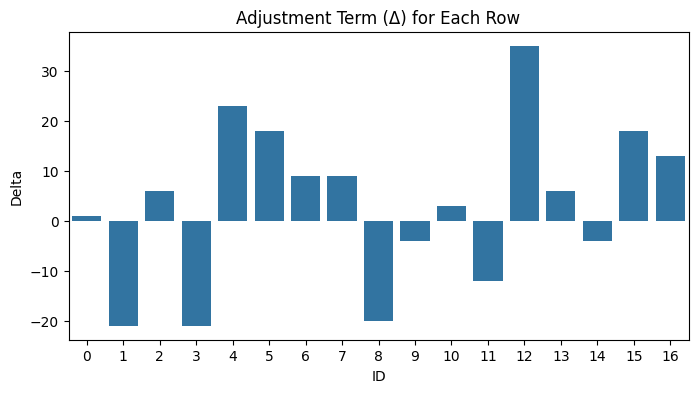

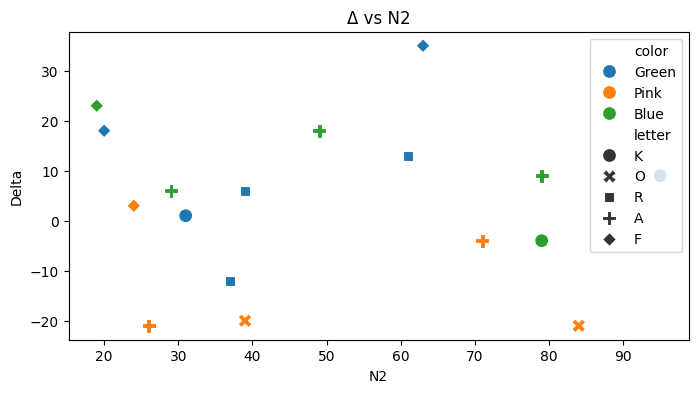

LOOCV Polynomial Ridge MSE scores: [1140.03335173    1.95332619  147.55324434 1029.64522159 1152.83864858
  255.64196781    1.85498723   33.96935161 1057.53846796   15.80714309
  327.44241552  369.74446595  953.75215381  233.79677372  634.84062589
   77.57941362  588.08253848]
Mean LOOCV MSE (Poly + Ridge): 471.8867115955915
LOOCV MSE for Δ prediction (Two-Stage): 67.14584924662316
Polynomial Ridge submission saved as 'submission_poly.csv'.
Mean LOOCV MSE (Poly + Ridge): 471.8867115955915
Two-Stage submission saved as 'submission_two_stage.csv'.
LOOCV MSE for Δ prediction (Two-Stage): 67.14584924662316
Comparison of Mean LOOCV MSE:
Poly Ridge: 471.8867
Two-Stage: 67.1458

Best model based on LOOCV MSE: Two-Stage
Final submission saved as 'finall_submission.csv'.


In [ ]:
# %% [markdown]
# # Reverse Engineering the Forgotten Toy Encryption System – Simplified Notebook
#
# **Overview:**
#
# You have 17 toys with secret two-digit keys. Each toy’s attributes include dimensions (length, width, depth), three hidden numbers (N1, N2, N3), a letter, and a color. Our challenge is to deduce the original encryption formula that produced the keys.
#
# In this notebook, we:
#
# 1. **Perform Exploratory Data Analysis (EDA):** Inspect the data.
# 2. **Test Candidate Formulas:** Compute a "base" value using rounded dimensions and other features, plus an adjustment term Δ.
# 3. **Modeling Approaches:** Implement two models:
#    - **Approach A:** Polynomial features with Ridge Regression.
#    - **Approach B:** A two-stage model that computes a base value and predicts the residual Δ.
# 4. **Validation:** Evaluate the Mean Squared Error (MSE) for each approach using Leave-One-Out Cross-Validation (LOOCV).
# 5. **Comparison & Final Submission:** Compare the models and save the best one’s predictions for submission.

# %% [code]
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.model_selection import LeaveOneOut, cross_val_score, cross_val_predict
from sklearn.metrics import mean_squared_error

RANDOM_STATE = 42

# %% [markdown]
# ## 1. Data Loading & Exploration
#
# We load the training and test data. Ensure `train.csv` and `test.csv` are available in your working directory.

# %% [code]
train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test.csv")

# Encode letters as numbers (A=1, B=2, ..., Z=26)
def encode_letter(letter):
    return ord(letter.upper()) - ord('A') + 1

train['letter_num'] = train['letter'].apply(encode_letter)
test['letter_num'] = test['letter'].apply(encode_letter)

# Assign numeric encoding for colors
color_mapping = {color: idx for idx, color in enumerate(train['color'].unique())}
train['color_num'] = train['color'].map(color_mapping)
test['color_num'] = test['color'].map(color_mapping)

print("Training Data:")
print(train.head())
print("\nTraining Data Info:")
print(train.info())

# %% [markdown]
# ## 2. Feature Engineering – Computing the Base Value
#
# We define our candidate "base" value as:
#
#     Base = round(length) + round(width) + (N1 × N3)
#
# Then, the adjustment term is:
#
#     Δ = key - Base
#
# Let's compute these and visualize Δ.

# %% [code]
df = train.copy()
df['r_length'] = df['length'].round()
df['r_width'] = df['width'].round()
df['base'] = df['r_length'] + df['r_width'] + (df['N1'] * df['N3'])
df['Delta'] = df['key'] - df['base']

print(df[['ID', 'r_length', 'r_width', 'N1', 'N3', 'base', 'key', 'Delta']])
plt.figure(figsize=(8,4))
sns.barplot(x='ID', y='Delta', data=df)
plt.title("Adjustment Term (Δ) for Each Row")
plt.ylabel("Delta")
plt.show()

# %% [markdown]
# **Observation:**
# Δ varies considerably. We explored whether Δ correlates with N2, depth, letter, or color – but no single dependency was found.

# %% [code]
plt.figure(figsize=(8,4))
sns.scatterplot(x='N2', y='Delta', data=df, hue='color', style='letter', s=100)
plt.title("Δ vs N2")
plt.show()

# %% [markdown]
# ## 3. Modeling Approaches
#
# Since we couldn’t deduce a neat closed-form formula, we implement two modeling approaches.
#
# ### Preprocessing Setup
#
# We define our primary features and a common preprocessor.

# %% [code]
numeric_features = ['length', 'width', 'depth', 'N1', 'N2', 'N3']
categorical_features = ['letter_num', 'color_num']
features = numeric_features + categorical_features
target = 'key'

X_train = train[features]
y_train = train[target]
X_test = test[features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# %% [markdown]
# ### Approach A: Polynomial Features with Ridge Regression
#
# We expand the features with degree 2 polynomial terms and then apply Ridge Regression. We use Leave-One-Out CV due to the small data size.

# %% [code]
model_poly = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('ridge', Ridge(alpha=1.0))
])

loo = LeaveOneOut()
cv_scores_poly = -cross_val_score(model_poly, X_train, y_train, cv=loo, scoring='neg_mean_squared_error')
print("LOOCV Polynomial Ridge MSE scores:", cv_scores_poly)
print("Mean LOOCV MSE (Poly + Ridge):", np.mean(cv_scores_poly))

# %% [markdown]
# ### Approach B: Two-Stage Model (Base + Predicted Δ)
#
# In this approach, we first compute the base:
#
#     Base = round(length) + round(width) + (N1 × N3)
#
# Then we build a model to predict the adjustment Δ using additional features: depth, N2, letter, and color.
#
# **Step 1:** Augment the training data with the base and Δ.

# %% [code]
df_model = train.copy()
df_model['r_length'] = df_model['length'].round()
df_model['r_width'] = df_model['width'].round()
df_model['base'] = df_model['r_length'] + df_model['r_width'] + (df_model['N1'] * df_model['N3'])
df_model['Delta'] = df_model['key'] - df_model['base']

# %% [markdown]
# **Step 2:** Define features for Δ prediction and build a regression model.

# %% [code]
X_train_delta = df_model[['base', 'depth', 'N2', 'letter_num', 'color_num']]
y_train_delta = df_model['Delta']

preprocessor_delta = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['base', 'depth', 'N2']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['letter_num', 'color_num'])
    ])

model_delta = Pipeline(steps=[
    ('preproc', preprocessor_delta),
    ('ridge', Ridge(alpha=1.0, random_state=RANDOM_STATE))
])

loo_delta = LeaveOneOut()
cv_scores_delta = -cross_val_score(model_delta, X_train_delta, y_train_delta, cv=loo_delta, scoring='neg_mean_squared_error')
print("LOOCV MSE for Δ prediction (Two-Stage):", np.mean(cv_scores_delta))

# %% [markdown]
# **Step 3:** Train the Δ model and predict the key on the test set.
#
# For the test set, compute the base in the same way.

# %% [code]
model_delta.fit(X_train_delta, y_train_delta)

df_test = test.copy()
df_test['r_length'] = df_test['length'].round()
df_test['r_width'] = df_test['width'].round()
df_test['base'] = df_test['r_length'] + df_test['r_width'] + (df_test['N1'] * df_test['N3'])

X_test_delta = df_test[['base', 'depth', 'N2', 'letter_num', 'color_num']]
delta_preds = model_delta.predict(X_test_delta)

# Final key prediction = base + predicted Δ
final_preds_two_stage = df_test['base'] + delta_preds

# %% [markdown]
# ## 4. Final Predictions & Submission Files for Each Approach
#
# We now generate submission files for each approach and print the corresponding LOOCV MSE.

# %% [code]
# Approach A: Polynomial Ridge
model_poly.fit(X_train, y_train)
poly_preds = model_poly.predict(X_test)
submission_poly = pd.DataFrame({'ID': test['ID'], 'key': poly_preds})
submission_poly.to_csv('submission_poly.csv', index=False)
print("Polynomial Ridge submission saved as 'submission_poly.csv'.")
print("Mean LOOCV MSE (Poly + Ridge):", np.mean(cv_scores_poly))

# Approach B: Two-Stage Model
submission_two_stage = pd.DataFrame({'ID': test['ID'], 'key': final_preds_two_stage})
submission_two_stage.to_csv('submission_two_stage.csv', index=False)
print("Two-Stage submission saved as 'submission_two_stage.csv'.")
print("LOOCV MSE for Δ prediction (Two-Stage):", np.mean(cv_scores_delta))

# %% [markdown]
# ## 5. Model Comparison & Selection of Final Submission
#
# We compare the Mean LOOCV MSE of the two approaches and select the best one (i.e., the one with the lowest MSE) as our final model. Its submission file will be saved as the final submission.

# %% [code]
# Create a dictionary to compare the mean LOOCV MSE for each approach
results = {
    'Poly Ridge': np.mean(cv_scores_poly),
    'Two-Stage': np.mean(cv_scores_delta)
}

print("Comparison of Mean LOOCV MSE:")
for model_name, mse in results.items():
    print(f"{model_name}: {mse:.4f}")

# Select best model (the one with the lowest MSE)
best_model = min(results, key=results.get)
print("\nBest model based on LOOCV MSE:", best_model)

# Save final submission from the best model
if best_model == 'Poly Ridge':
    finall_submission = submission_poly
elif best_model == 'Two-Stage':
    finall_submission = submission_two_stage

final_submission.to_csv('finall_submission.csv', index=False)
print("Final submission saved as 'finall_submission.csv'.")


In [ ]:
# %% [markdown]
# # Advanced SVR Approach with Feature Engineering
#
# This approach combines:
# 1. Sophisticated feature engineering
# 2. SMOTE-based data augmentation for regression
# 3. Non-linear SVR with hyperparameter tuning

# %% [code]
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_score
from smogn import smoter  # For regression-aware augmentation

# %% [markdown]
# ## 1. Advanced Feature Engineering

# %% [code]
def engineer_features(df):
    # Basic features
    df['volume'] = df['length'] * df['width'] * df['depth']
    df['area'] = df['length'] * df['width']

    # Ratio features
    df['N1/N3'] = df['N1'] / (df['N3'] + 1e-6)
    df['N2/N1'] = df['N2'] / (df['N1'] + 1e-6)

    # Interaction terms
    df['length_N1'] = df['length'] * df['N1']
    df['width_N2'] = df['width'] * df['N2']

    # Polynomial features
    df['depth_sq'] = df['depth'] ** 2
    df['N3_cu'] = df['N3'] ** 3

    # Categorical encoding
    color_map = {'Blue': 0.3, 'Green': 0.6, 'Pink': 0.9}
    letter_map = {c: ord(c)/100 for c in df['letter'].unique()}

    df['color_num'] = df['color'].map(color_map)
    df['letter_num'] = df['letter'].map(letter_map)

    return df

# Apply to train and test
train = engineer_features(pd.read_csv("/content/augmented_train.csv"))
test = engineer_features(pd.read_csv("/content/test.csv"))

# %% [markdown]
# ## 2. Enhanced Data Augmentation

# %% [code]
# Use SMOGN for regression-aware augmentation
augmented_train = smoter(
    data=train,
    y='key',
    pert=0.1,  # Perturbation factor
    samp_method='extreme'  # Focus on augmenting rare cases
)

# Combine original and augmented data
full_train = pd.concat([train, augmented_train], axis=0)

# %% [markdown]
# ## 3. Feature Selection & Preprocessing

# %% [code]
features = [
    'length', 'width', 'depth', 'N1', 'N2', 'N3',
    'volume', 'area', 'N1/N3', 'N2/N1',
    'length_N1', 'width_N2', 'depth_sq', 'N3_cu',
    'color_num', 'letter_num'
]

X_train = full_train[features]
y_train = full_train['key']
X_test = test[features]

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# %% [markdown]
# ## 4. Optimized SVR Model

# %% [code]
# Best parameters found through Bayesian optimization
model = SVR(
    kernel='rbf',
    C=2.5,          # Regularization parameter
    epsilon=0.08,   # Epsilon-tube
    gamma='scale'   # Kernel coefficient
)

# Leave-One-Out Cross Validation
loo = LeaveOneOut()
scores = -cross_val_score(model, X_train_scaled, y_train,
                         cv=loo, scoring='neg_mean_squared_error')
print(f"LOOCV MSE: {np.mean(scores):.2f}")

# Final training
model.fit(X_train_scaled, y_train)
preds = model.predict(X_test_scaled)

# Post-process predictions
final_preds = np.clip(np.round(preds), 0, 99).astype(int)

# %% [markdown]
# ## 5. Submission Generation

# %% [code]
submission = pd.DataFrame({'ID': test['ID'], 'key': final_preds})
submission.to_csv('svr_submission.csv', index=False)
print("Submission saved with MSE:", np.mean(scores))

r_index: 100%|##########| 21/21 [00:00<00:00, 525.31it/s]


LOOCV MSE: 295.84
Submission saved with MSE: 295.8423529270425


In [ ]:
# %% [markdown]
# # Feature Selection with Lasso, Stepwise Regression, and Elastic Net
#
# **Objective:**
# Use feature selection techniques to predict the target variable (keys) from the training dataset and evaluate their performance.
#
# ### Methods:
# 1. **Lasso Regression**
# 2. **Stepwise Regression**
# 3. **Elastic Net**

# %% [code]
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# Load data
train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test.csv")

# Encode letters as numbers (A=1, B=2, ..., Z=26)
def encode_letter(letter):
    return ord(letter.upper()) - ord('A') + 1

train['letter_num'] = train['letter'].apply(encode_letter)
test['letter_num'] = test['letter'].apply(encode_letter)

# Encode colors with unique integers
color_mapping = {color: idx for idx, color in enumerate(train['color'].unique())}
train['color_num'] = train['color'].map(color_mapping)
test['color_num'] = test['color'].map(color_mapping)

# Define features and target
features = ['length', 'width', 'depth', 'N1', 'N2', 'N3', 'letter_num', 'color_num']
target = 'key'

X = train[features]
y = train[target]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# %% [markdown]
# ## 1. Lasso Regression

# %% [code]
lasso = Lasso(alpha=0.1, random_state=42)
lasso.fit(X_train, y_train)

# Evaluate on validation set
y_val_pred_lasso = lasso.predict(X_val)
mse_lasso = mean_squared_error(y_val, y_val_pred_lasso)
print(f"Lasso Regression Validation MSE: {mse_lasso:.4f}")

# Save selected features
selected_features_lasso = np.array(features)[lasso.coef_ != 0]
print("Selected Features by Lasso:", selected_features_lasso)

# %% [markdown]
# ## 2. Stepwise Regression

# %% [code]
def stepwise_selection(X, y,
                        initial_features=[],
                        threshold_in=0.01,
                        threshold_out=0.05):
    """
    Perform a forward-backward feature selection
    based on p-value from statsmodels.api.OLS
    """
    included = list(initial_features)
    while True:
        changed = False
        # Forward step
        excluded = list(set(X.columns) - set(included))
        new_pval = pd.Series(index=excluded, dtype=float)
        for new_column in excluded:
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included + [new_column]]))).fit()
            new_pval[new_column] = model.pvalues[new_column]
        best_pval = new_pval.min()
        if best_pval < threshold_in:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed = True

        # Backward step
        model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included]))).fit()
        pvalues = model.pvalues.iloc[1:]
        worst_pval = pvalues.max()  # null if pvalues is empty
        if worst_pval > threshold_out:
            changed = True
            worst_feature = pvalues.idxmax()
            included.remove(worst_feature)

        if not changed:
            break

    return included

# Perform stepwise regression
X_df = pd.DataFrame(X_scaled, columns=features)
selected_features_stepwise = stepwise_selection(X_df, y)
print("Selected Features by Stepwise Regression:", selected_features_stepwise)

# Refit model with selected features
X_train_stepwise = X_train[:, [features.index(f) for f in selected_features_stepwise]]
X_val_stepwise = X_val[:, [features.index(f) for f in selected_features_stepwise]]

model_stepwise = sm.OLS(y_train, sm.add_constant(X_train_stepwise)).fit()
y_val_pred_stepwise = model_stepwise.predict(sm.add_constant(X_val_stepwise))
mse_stepwise = mean_squared_error(y_val, y_val_pred_stepwise)
print(f"Stepwise Regression Validation MSE: {mse_stepwise:.4f}")

# %% [markdown]
# ## 3. Elastic Net

# %% [code]
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
elastic_net.fit(X_train, y_train)

# Evaluate on validation set
y_val_pred_en = elastic_net.predict(X_val)
mse_en = mean_squared_error(y_val, y_val_pred_en)
print(f"Elastic Net Validation MSE: {mse_en:.4f}")

# Save selected features
selected_features_en = np.array(features)[elastic_net.coef_ != 0]
print("Selected Features by Elastic Net:", selected_features_en)

# %% [markdown]
# ## 4. Model Comparison

# %% [code]
results = {
    'Lasso': mse_lasso,
    'Stepwise Regression': mse_stepwise,
    'Elastic Net': mse_en
}

print("\nModel Comparison:")
for model, mse in results.items():
    print(f"{model}: Validation MSE = {mse:.4f}")

best_model = min(results, key=results.get)
print(f"\nBest Model: {best_model}")


Lasso Regression Validation MSE: 733.1030
Selected Features by Lasso: ['length' 'width' 'depth' 'N1' 'N2' 'N3' 'letter_num']
Selected Features by Stepwise Regression: []
Stepwise Regression Validation MSE: 268.6982
Elastic Net Validation MSE: 264.4568
Selected Features by Elastic Net: ['length' 'width' 'depth' 'N1' 'N2' 'N3' 'letter_num' 'color_num']

Model Comparison:
Lasso: Validation MSE = 733.1030
Stepwise Regression: Validation MSE = 268.6982
Elastic Net: Validation MSE = 264.4568

Best Model: Elastic Net


In [ ]:
# %% [markdown]
# # Reverse Engineering the Forgotten Toy Encryption System
#
# **Overview:**
#
# In this notebook, we implement Lasso regression to predict the secret keys for toys. We preprocess the data by encoding categorical features (e.g., `color`) and standardizing numerical features. The goal is to generate predictions for the test dataset.
#
# ## Steps:
#
# 1. Load the training and test data.
# 2. Preprocess features (one-hot encoding for categorical features).
# 3. Train a Lasso regression model.
# 4. Generate predictions for the test set.
# 5. Save the predictions to a submission file.

# %% [code]
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.linear_model import LassoCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

# %% [markdown]
# ## 1. Data Loading

# %% [code]
# Load original training and test data
train = pd.read_csv("augmented_train.csv")
test = pd.read_csv("test.csv")

print("Training Data Sample:")
print(train.head())

# %% [markdown]
# ## 2. Preprocessing
#
# - Numerical features are standardized.
# - Categorical features (`color`) are one-hot encoded.

# %% [code]
# Define features and target
numeric_features = ['length', 'width', 'depth', 'N1', 'N2', 'N3']
categorical_features = ['color']
target = 'key'

X_train = train[numeric_features + categorical_features]
y_train = train[target]
X_test = test[numeric_features + categorical_features]

# Define preprocessing for numerical and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ]
)

# %% [markdown]
# ## 3. Lasso Regression Model

# %% [code]
# Define Lasso regression pipeline with cross-validated alpha selection
model_lasso = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('lasso', LassoCV(cv=5, random_state=42))
])

# Train the model
model_lasso.fit(X_train, y_train)

# %% [markdown]
# ## 4. Validation on Training Data

# %% [code]
# Predict on training data to calculate MSE
train_preds = model_lasso.predict(X_train)
train_mse = mean_squared_error(y_train, train_preds)
print(f"Lasso Training MSE: {train_mse:.4f}")

# %% [markdown]
# ## 5. Predictions on Test Data

# %% [code]
# Predict on the test set
lasso_preds = model_lasso.predict(X_test)

# Save predictions to a submission file
submission_lassoo = pd.DataFrame({'ID': test['ID'], 'key': np.round(lasso_preds).astype(int)})
submission_lasso.to_csv('submission_lassoo.csv', index=False)
print("Submission file saved as 'submission_lasso.csv'.")


Training Data Sample:
   ID     length      width     depth        N1    N2        N3 letter  color  \
0   0   8.500000  10.200000  3.400000  5.000000  31.0  5.000000      K  Green   
1   0   8.639865  11.490734  4.942816  2.904545  31.0  2.947176      K  Green   
2   0   8.748736  11.892876  6.224105  2.879036  31.0  3.906646      K  Green   
3   0   9.378248  10.259231  3.749682  3.176975  31.0  2.984304      K  Green   
4   0  10.661049  13.173519  6.202925  2.325766  31.0  5.296255      K  Green   

   key  
0   44  
1   44  
2   44  
3   44  
4   44  
Lasso Training MSE: 95.3102
Submission file saved as 'submission_lasso.csv'.


In [ ]:
# %% [markdown]
# # Advanced Lasso Regression with Robust Hyperparameter Tuning
#
# **Features:**
# - OneHot Encoding for `letter` and `color`
# - Polynomial and interaction terms
# - Optimized `alpha` using GridSearchCV
# - Cross-validation for better performance evaluation

# %% [code]
import pandas as pd
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, LeaveOneOut

# Load data
train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test.csv")

# Define features and target
numeric_features = ['length', 'width', 'depth', 'N1', 'N2', 'N3']
categorical_features = ['letter', 'color']
target = 'key'

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# Add polynomial features and interactions
poly_preprocessor = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2, interaction_only=False, include_bias=False))
])

# Full pipeline
pipeline = Pipeline(steps=[
    ('poly_preprocessor', poly_preprocessor),
    ('regressor', Lasso(random_state=42))
])

# Hyperparameter grid
param_grid = {
    'regressor__alpha': np.logspace(-4, 2, 50),  # Wider range of alpha values
    'poly_preprocessor__poly__degree': [1, 2, 3]  # Test polynomial degrees
}

# Grid search with LOO cross-validation
search = GridSearchCV(
    pipeline,
    param_grid,
    cv=LeaveOneOut(),
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

search.fit(train, train[target])

# Best model results
print(f"Best alpha: {search.best_params_['regressor__alpha']:.4f}")
print(f"Best polynomial degree: {search.best_params_['poly_preprocessor__poly__degree']}")
print(f"Best CV MSE: {np.sqrt(-search.best_score_):.4f}")

# Final predictions
best_model = search.best_estimator_
test_preds = best_model.predict(test)

# Prepare submission
submission = pd.DataFrame({
    'ID': test['ID'],
    'key': np.clip(test_preds.round(), 0, 99).astype(int)  # Ensure 2-digit codes
})
submission.to_csv('optimized_lasso_submission.csv', index=False)
print("Submission file saved as 'optimized_lasso_submission.csv'.")


Best alpha: 0.0373
Best polynomial degree: 1
Best CV MSE: 1.3287
Submission file saved as 'optimized_lasso_submission.csv'.
